<p align="center">
<img src="Images/sorbonne_logo.png" alt="Logo" width="300"/>
</p>

# **Module 6 - IRL**

* **Author**: Elia Landini
* **Student ID**: 12310239
* **Course**: EESM2-Financial Economics 
* **Supervisor**: Jean-Bernard Chatelain
* **Reference Repository**: https://github.com/EliaLand/IRL-FAVAR_money_endogeneity

### **1) REQUIREMENTS SET-UP**

In [204]:
# Requirements.txt file installation
# !pip install -r requirements.txt

In [205]:
# Libraries Import
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

### **2) IMPORT & RESTRUCTURING**

In [206]:
# Transformed df Import
jp_trans_df = pd.read_csv("Data/Transformed/jp_trans_df.csv")

In [207]:
# Variables Remapping 
col_map = {
    "LogDiff-Monetary Aggregates - M1 (JPY)": "M1",
    "LogDiff-Monetary Aggregates - M2 (JPY)": "M2",
    "LogDiff-Monetary Aggregates - M3 (JPY)": "M3",
    "LogDiff-Total Treasury Reserves (- Gold)": "reserves",
    "LogDiff-BoJ’s Total Assets (100 Million Yen)": "boj_assets",
    "LogDiff-USD-JPY reer CPI-based (Index 2015=100)": "reer",
    "LogDiff-JPY-USD Spot Exchange Rate": "fx",
    "LogDiff-HICP (SA)": "inflation",
    "LogDiff-1615.T-Price": "nikkei",                            
    "LogDiff-Call Money/Interbank Immediate (%)": "call_rate_logdiff",
    "AR(1)detrend-Total Credit - General Government (%GDP)": "credit_gov",
    "AR(1)detrend-Total Credit - Households & NPISHs (%GDP)": "credit_hh",
    "AR(1)detrend-Total Credit - Private Non-Financial (%GDP)": "credit_pnf",
    "AR(1)detrend-10-Year Gov Bond Yields (%)": "10y_bond_yield",
    "AR(1)detrend-Call Money/Interbank Immediate (%)": "call_rate",
    "AR(1)detrend-Est. 1-year Neutral Interest Rate (%)": "neutral_rate_1y",
    "AR(1)detrend-Est. 10-year Neutral Interest Rate (%)": "neutral_rate_10y",
    "AR(1)detrend-Central Government Debt (% GDP)": "gov_debt",
    "AR(1)detrend-Domestic Private Debt Securities (% GDP)": "priv_debt_sec",
    "AR(1)detrend-Domestic Public Debt Securities (% GDP)": "pub_debt_sec",
    "AR(1)detrend-Loan Interest Rate (%)": "loan_rate",
    "AR(1)detrend-Deposit Interest Rate (%)": "deposit_rate",
    "AR(1)detrend-10-Year US T-Bills Yield (%)": "us_tbill",
    "AR(1)detrend-CBOE-VIX": "vix",
    "HPfilter-Real GDP (billions chained 2015 JPY)": "output_gap",
}
jp_core_df = jp_trans_df.copy().rename(columns=col_map)
jp_core_df.to_csv("Data/jp_core_df.csv", index=False)
jp_core_df

,Country,Time,M1,M2,M3,reserves,reer,fx,inflation,nikkei,...,neutral_rate_1y,neutral_rate_10y,gov_debt,priv_debt_sec,pub_debt_sec,loan_rate,deposit_rate,us_tbill,vix,output_gap
0,JP,1950-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,JP,1951-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,JP,1951-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,JP,1951-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,JP,1951-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,JP,2025-12,NaN,NaN,NaN,0.005796,-0.012713,0.004976,NaN,0.043927,...,0.002655,0.002863,NaN,NaN,NaN,0.264511,0.004569,0.041292,-4.176314,-0.001618
901,JP,2026-01,NaN,NaN,NaN,0.005291,-0.012815,0.004706,NaN,0.124617,...,NaN,NaN,NaN,NaN,NaN,NaN,0.006569,0.062536,0.032409,NaN
902,JP,2026-02,NaN,NaN,NaN,0.007443,0.000443,-0.009937,NaN,0.079644,...,NaN,NaN,NaN,NaN,NaN,NaN,0.073583,-0.095179,2.525659,NaN
903,JP,2026-03,NaN,NaN,NaN,NaN,NaN,0.022826,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112260,6.349080,NaN


### **3) STATE VARIABLE CONSTRUCTION**

In [208]:
# State Variable Construction
df = jp_core_df.copy()

# /////////////
# Bank of Japan
# /////////////
# (!!!) The BoJ range of action incorporates both the continuous range of selection of the interest rate (policy intrument) and the adoption of a policy regime (ycc/qe)
df["qe_proxy"] = df["boj_assets"].fillna(0)

# ////////////////
# Commercial Banks
# ////////////////
# Net Interest Margin (banks" profit margin)
df["nim"] = df["loan_rate"] - df["deposit_rate"]
# Default proxy
# (!!!) Negative function of the credit_pnf growth rate, as a decrease of credit can be interpretated as an increase in the probability of firms default
# (!!!) It can"t go below zero
df["default_proxy"]  = (-df["credit_pnf"].fillna(0)).clip(lower=0)
# Capital Stress
# (!!!) lower nim increases capital stress, vix increases, and credit to pnf decreases 
df["capital_stress"] = (-df["nim"].fillna(0)
                        + df["vix"].fillna(0)
                        - df["credit_pnf"].fillna(0))

# //////////
# Households
# //////////
# Households" Debt Accumulation Proxy
df["hh_debt_proxy"] = df["credit_hh"].fillna(0).rolling(24, min_periods=6).sum()
# Real Cost of Borrowing for Households
df["real_rate"] = df["call_rate"] - df["inflation"]

In [209]:
# Set of Core Variables Construction
core_cols = [
    "inflation",
    "call_rate",
    "output_gap",
    "credit_pnf",
    "credit_hh",
    "gov_debt",
    "fx",
    "vix",
    "loan_rate",
    "deposit_rate",
    "nim",
    "boj_assets",
    "10y_bond_yield",
    "real_rate",
    "M3", 
    "qe_proxy",
    "default_proxy",
    "capital_stress",
    "hh_debt_proxy"
]
jp_state_df = df[["Country", "Time"] + core_cols].dropna().copy()
jp_state_df.to_csv("Data/jp_state_df.csv", index=False)
jp_state_df

,Country,Time,inflation,call_rate,output_gap,credit_pnf,credit_hh,gov_debt,fx,vix,...,deposit_rate,nim,boj_assets,10y_bond_yield,real_rate,M3,qe_proxy,default_proxy,capital_stress,hh_debt_proxy
569,JP,1998-05,1.032947,-0.010446,-0.007774,0.037320,-0.004204,-0.439234,0.023571,-0.765213,...,-0.094829,0.086047,-0.036587,-0.205574,-1.043393,0.004179,-0.036587,0.000000,-0.888580,-0.129739
570,JP,1998-06,-0.427880,0.013796,-0.006858,0.037320,-0.004204,-0.439234,0.039496,1.002092,...,0.013456,0.005699,-0.023495,-0.110000,0.441675,0.000768,-0.023495,0.000000,0.959074,-0.129739
571,JP,1998-07,-3.399241,-0.018700,-0.004739,1.337320,0.095796,-0.439234,0.003251,-1.399135,...,0.100502,-0.044476,-0.040035,0.147226,3.380541,0.004922,-0.040035,0.000000,-2.691980,-0.129739
572,JP,1998-08,-4.032639,0.018703,-0.004053,0.041528,-0.003848,-0.439234,0.027273,11.727565,...,0.082153,-0.087064,0.052921,-0.175812,4.051342,0.004464,0.052921,0.000000,11.773101,-0.129739
573,JP,1998-09,5.911240,-0.100781,-0.003498,0.041528,-0.003848,-0.439234,-0.073105,8.463197,...,-0.206328,0.195482,0.025754,-0.395030,-6.012020,0.003470,0.025754,0.000000,8.226187,-0.129739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,JP,2021-09,5.691701,0.013023,-0.000929,-0.035191,-0.016309,-0.405006,0.002803,2.046939,...,0.001344,0.053322,-0.003656,0.038998,-5.678677,0.002400,-0.003656,0.035191,2.028808,4.009240
850,JP,2021-10,-7.746593,-0.003877,0.009121,1.064809,-0.016309,-0.405006,0.026520,-1.899905,...,0.004282,-0.060265,0.001560,0.024301,7.742716,0.003444,0.001560,0.000000,-2.904450,3.525262
851,JP,2021-11,2.639222,-0.010918,0.007280,-0.031630,-0.016309,-0.405006,0.007429,0.384726,...,0.001091,-0.052362,0.004170,-0.050498,-2.650141,0.002083,0.004170,0.031630,0.468718,3.539503
852,JP,2021-12,0.904571,0.013982,0.005531,-0.031630,-0.016309,-0.405006,-0.001160,2.705635,...,0.004227,0.048406,-0.006133,0.014200,-0.890589,0.002447,-0.006133,0.031630,2.688858,3.553745


### **4) TRANSITION DYNAMICS**

In [210]:
# Transition Dynamics 

df = jp_state_df.copy() 

# Lead Extraction 
# (!!!) We define the dependent side of the regression as the lead t+1 of each variable to assess how the state evolves following the impact of the action bundle executed by the agents 
# Output Gap
df["output_gap_t+1"] = df["output_gap"].shift(-1)
# Inflation
df["inflation_t+1"] = df["inflation"].shift(-1)
# Default Proxy
df["default_proxy_t+1"] = df["default_proxy"].shift(-1)
# Capital Stress
df["capital_stress_t+1"] = df["capital_stress"].shift(-1)
# Household Debt Proxy
df["hh_debt_proxy_t+1"] = df["hh_debt_proxy"].shift(-1)
# Negative Component Output Gap 
# (!!!) It takes the maximum between 0 and recession periods that since they have a minus in front (-df["output_gap_t+1"]) become negative and then are teaken into account, otherwise during normal periods of positive growth, the default rate is indifferent so 0
df["negative_output_gap_t+1"] = np.maximum(0, -df["output_gap_t+1"].fillna(0))
# Credit Efficiency
# (!!!) The minimum between what banks supply and what households demand
# (!!!) Even if the BoJ floods banks with reserves, if households are deleveraging (credit_hh < 0), effective credit is negative regardless
df["credit_eff"] = np.minimum(df["credit_pnf"].fillna(0),
                              df["credit_hh"].fillna(0))

# ////////////////////////////////////
# Equation 1 — Output Gap Transmission
# ////////////////////////////////////
X1 = sm.add_constant(df[["output_gap","credit_eff","capital_stress"]].rename(
     columns={"output_gap":"output_gap_t","credit_eff":"credit_eff_t","capital_stress":"capital_stress_t"}))
m1 = sm.OLS(df["output_gap_t+1"], X1, missing="drop").fit()

# ///////////////////////////////////
# Equation 2 — Inflation Transmission
# ///////////////////////////////////
# (!!!) From equation 1 the outgap change transmits to inflation
X2 = sm.add_constant(df[["inflation","output_gap_t+1"]].rename(
     columns={"inflation":"inflation_t"}))
m2 = sm.OLS(df["inflation_t+1"], X2, missing="drop").fit()

# ///////////////////////////////////////
# Equation 3 — Default Proxy Transmission
# ///////////////////////////////////////
# (!!!) We transform output gap to negative, as the contraction of output tends to lead to higher distress for firms corresponding to expected higher default rates
# (!!!) Commercial Banks Default Index (impossible to find a better proxy)
# (!!!) More credit, more exposure
X3 = sm.add_constant(df[["default_proxy","negative_output_gap_t+1","credit_pnf"]].rename(
     columns={"default_proxy":"default_proxy_t", "credit_pnf":"credit_pnf_t"}))
m3 = sm.OLS(df["default_proxy_t+1"], X3, missing="drop").fit()

# ////////////////////////////////////////  
# Equation 4 — Capital Stress Transmission
# ////////////////////////////////////////
# (!!!) Rising defaults directly tighten capital, losses eat into equity
# (!!!) NIM compression (from rate cuts) squeezes the bank's ability to rebuild capital organically through retained earnings. This creates the NIM-capital-lending doom loop that Japan experienced: cuts → lower NIM → weaker banks → less lending
X4 = sm.add_constant(df[["capital_stress","default_proxy_t+1","nim"]].rename(
     columns={"capital_stress":"capital_stress_t", "nim":"nim_t"}))
m4 = sm.OLS(df["capital_stress_t+1"], X4, missing="drop").fit()

# ////////////////////////////////////////  
# Equation 5 — Household Debt Transmission
# ////////////////////////////////////////
X5 = sm.add_constant(df[["hh_debt_proxy","credit_hh","real_rate"]].rename(
     columns={"hh_debt_proxy":"hh_debt_proxy_t", "credit_hh":"credit_hh_t", "real_rate":"real_rate_t"}))
m5 = sm.OLS(df["hh_debt_proxy_t+1"], X5, missing="drop").fit()

In [211]:
# Equations' Model Params Loop 
for target, model in [("Output Gap t+1", m1), 
                      ("Inflation t+1", m2), 
                      ("Default Proxy t+1", m3), 
                      ("Capital Stress t+1", m4), 
                      ("Household Debt Proxy t+1", m5)]:
    print(f"\n////////////////////// {target} (R²={model.rsquared:.4f}) //////////////////////")
# (!!!) .tables[1] is great to summarize the core statistics (params, p-values) of OLS results
    print(model.summary().tables[1])


////////////////////// Output Gap t+1 (R²=0.5613) //////////////////////
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0001      0.000     -0.260      0.795      -0.001       0.001
output_gap_t         0.7518      0.041     18.264      0.000       0.671       0.833
credit_eff_t        -0.0006      0.001     -1.217      0.225      -0.002       0.000
capital_stress_t    -0.0003    9.3e-05     -3.670      0.000      -0.001      -0.000

////////////////////// Inflation t+1 (R²=0.0418) //////////////////////
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0620      0.164      0.377      0.706      -0.262       0.386
inflation_t        0.1633      0.059      2.764      0.006       0.047       0.280
output_gap_

In [212]:
# Model Transition Params Storage
# (!!!) Params saving for agents training 
transition_params_ols = {
# From Equation 1
    "alpha": m1.params.get("output_gap_t").round(4),
    "beta": m1.params.get("credit_eff_t").round(4),
    "gamma": m1.params.get("capital_stress_t").round(4),
# From Equation 2
    "rho": m2.params.get("inflation_t").round(4),
    "lam": m2.params.get("output_gap_t+1").round(4),
# From Equation 3
    "delta_d": m3.params.get("default_proxy_t").round(4),
    "phi": m3.params.get("negative_output_gap_t+1").round(4),
    "psi": m3.params.get("credit_pnf_t").round(4),
# From Equation 4
    "kappa": m4.params.get("capital_stress_t").round(4),
    "theta": m4.params.get("default_proxy_t+1").round(4),
    "mu": m4.params.get("nim_t").round(4),
# From Equation 5
    "delta_D": m5.params.get("hh_debt_proxy_t").round(4),
    "zeta": m5.params.get("credit_hh_t").round(4),
    "xi": m5.params.get("real_rate_t").round(4)
}
print(transition_params_ols)

{'alpha': 0.7518, 'beta': -0.0006, 'gamma': -0.0003, 'rho': 0.1633, 'lam': 26.9646, 'delta_d': -0.2198, 'phi': -12.3928, 'psi': -0.0544, 'kappa': 0.0246, 'theta': 1.2051, 'mu': -2.2835, 'delta_D': 0.9892, 'zeta': 0.0232, 'xi': -0.0064}


### **5) INVERSE REINFORCEMENT LEARNING AGENTS' REWARD FUNCTIONS (IRL)**

In [213]:
# Inverse Reinforcement Learning Agents' Reward Functions (IRL)
# (!!!) Infers each agent's implicit reward function from their observed historical actions, using linear Maximum-Entropy IRL
# (!!!) All features are standardised so coefficients are comparable across variables with different units
# (!!!) In normal RL we say: "here is the reward, go find the best action"
# (!!!) Inverse RL flips it: "here are the actions the agent actually took over 25 years, what reward function must they have been maximising?"

df = jp_state_df.copy()
df = df.set_index(pd.to_datetime(df["Time"])).drop(columns="Time")

# BoJ explicit inflation target (annual 2%)
# https://www.boj.or.jp/en/mopo/outline/target.htm
pi_star = 2

# Derived metrics
# BoJ Reward Function, inflation component (the second one is outpuit stabilization, both of them weighted)
df["inflation_gap"] = df["inflation"] - pi_star
# BoJ Action 1: call rate variation 
df["boj_action1_rate"] = df["call_rate"].diff()
# BoJ Action 2: Quantitative Easing/YCC 
df["boj_action2_qe"] = df["qe_proxy"]
# Commercial Bank Action 1: Credit supply 
df["bank_action1"] = df["credit_pnf"]
# Households Action 1: Credit demand (temporal budget constraint)
df["hh_action1"] = df["credit_hh"]

In [214]:
# ///////////////////
# Bank of Japan - IRL
# ///////////////////
# (!!!) You observe that the BoJ cut rates in 1999. Why? Because inflation was too low? Because output was falling? Because banks were stressed? 


# Claude comment of this (low R squared):
# (!!!) The low R² values (3% and 5%) are not a bug but they are a structural feature of Japanese monetary policy that makes linear IRL fundamentally unsuited to the BoJ:
# Reason 1 = The Dependent Variable Is Almost Always Zero
# boj_action1_rate = callrate.diff() measures the change in the call rate each month, the BoJ adopted ZIRP in February 1999 and held rates at essentially zero until 2022, with only one brief and failed lift in 2000. This means out of your 285 observations, the overwhelming majority of rows have boj_action1_rate ≈ 0
# OLS minimises squared errors, with a near-constant dependent variable, it finds that the intercept alone fits better than any combination of regressor
# Reason 2 = The BoJ Operates in Regimes, Not on a Continuous Reaction Function
# IRL fits one linear slope across the entire 1998–2022 sample, but the BoJ actually operated under at least four structurally distinct regimes:
# ZIRP (1999–2000): Rate fixed at floor, QE off, no linear response possible
# Lost decade (2001–2012): Rate fixed again, QE and reserve targeting introduced
# Abenomics (2013–2016): Massive QE, YCC not yet active
# YCC (2016–2022): Rate fixed, QE calibrated to a yield curve target
# Averaging a Taylor-rule slope across these four regimes produces coefficients that describe none of them accurately, hence near-zero R². This is exactly why regime-shifting IRL gives more interpretable omega values, at least within each sub-period, the regression faces a more homogeneous reaction function
# Reason 3 = The BoJ Reacts to Forecasts, Not to Current Observations
# Your features (inflation_gap, output_gap) are contemporaneous realised values. The BoJ publicly bases decisions on its Outlook for Economic Activity and Prices, forward-looking staff projections. A central bank that reacts to its own forecast will appear to have no relationship with current data, because those forecasts are unobserved in your dataset
# Reason 4 = Endogeneity Collapses Coefficients
# capital_stress and output_gap are partly caused by the BoJ's own past actions. OLS with endogenous regressors produces biased, attenuated coefficients that converge toward zero, which is exactly the pattern you see: every coefficient is indistinguishable from zero at p < 0.05



boj_features = ["inflation_gap","output_gap", "capital_stress", "gov_debt", "fx", "vix"]
# BoJ set of actions (dependent)
boj_df = df[["boj_action1_rate", "boj_action2_qe"] + boj_features].dropna()

# Rescaling/Normalization 
# (!!!) We look into feature columns, learn their average and spread, and then rescale them
boj_scaler = StandardScaler()
boj_X = pd.DataFrame(boj_scaler.fit_transform(boj_df[boj_features]),
                     columns=boj_features, index=boj_df.index)

# Inverse Inference
# (!!!) How the BoJ acted in the past with respect to its range of actions while observing certain levels of features 
m_boj_rate = sm.OLS(boj_df["boj_action1_rate"], sm.add_constant(boj_X)).fit()
m_boj_qe = sm.OLS(boj_df["boj_action2_qe"], sm.add_constant(boj_X)).fit()

In [215]:
# /////////////////////
# Commercial Bank - IRL
# /////////////////////
bank_features = ["nim", "capital_stress", "default_proxy", "call_rate", "credit_hh"]
bank_df = df[["bank_action1"] + bank_features].dropna()

bank_scaler = StandardScaler()
bank_X = pd.DataFrame(bank_scaler.fit_transform(bank_df[bank_features]),
                      columns=bank_features, index=bank_df.index)

m_bank = sm.OLS(bank_df["bank_action1"], sm.add_constant(bank_X)).fit()

In [216]:
# ////////////////
# Households - IRL
# ////////////////
hh_features = ["real_rate", "output_gap", "inflation", "deposit_rate", "hh_debt_proxy"]
hh_df = df[["hh_action1"] + hh_features].dropna()

hh_scaler = StandardScaler()
hh_X = pd.DataFrame(hh_scaler.fit_transform(hh_df[hh_features]),
                    columns=hh_features, index=hh_df.index)

m_hh = sm.OLS(hh_df["hh_action1"], sm.add_constant(hh_X)).fit()

In [217]:
# IRL' Model Params Loop 
for target, model in [("BoJ Rate", m_boj_rate), 
                      ("BoJ QE", m_boj_qe), 
                      ("Bank", m_bank), 
                      ("Household", m_hh)]:
    print(f"\n////////////////////// {target} (R²={model.rsquared:.4f}) //////////////////////")
# (!!!) .tables[1] is great to summarize the core statistics (params, p-values) of OLS results
    print(model.summary().tables[1])


////////////////////// BoJ Rate (R²=0.0309) //////////////////////
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           6.175e-05      0.002      0.034      0.973      -0.003       0.004
inflation_gap      0.0008      0.002      0.435      0.664      -0.003       0.004
output_gap        -0.0006      0.002     -0.300      0.764      -0.004       0.003
capital_stress    -0.0109      0.008     -1.412      0.159      -0.026       0.004
gov_debt          -0.0008      0.002     -0.425      0.671      -0.004       0.003
fx                -0.0016      0.002     -0.850      0.396      -0.005       0.002
vix                0.0062      0.008      0.819      0.413      -0.009       0.021

////////////////////// BoJ QE (R²=0.0534) //////////////////////
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [218]:
# IRL Inferred Omega 
# (!!!) how much does this agent react to this variable?

# Bank of Japan 
omega_boj_rate_gen = [m_boj_rate.params.get("inflation_gap").round(4),
                  m_boj_rate.params.get("output_gap").round(4),
                  m_boj_rate.params.get("capital_stress").round(4),
                  m_boj_rate.params.get("gov_debt").round(4)]
omega_boj_qe_gen = [m_boj_qe.params.get("inflation_gap").round(4),
                m_boj_qe.params.get("output_gap").round(4),
                m_boj_qe.params.get("capital_stress").round(4),
                m_boj_qe.params.get("gov_debt").round(4)]

# Commercial Bank
omega_bank_gen = [m_bank.params.get("nim").round(4),
              m_bank.params.get("capital_stress").round(4),
              m_bank.params.get("default_proxy").round(4),
              m_bank.params.get("credit_hh").round(4)]

# Households
omega_hh_gen = [m_hh.params.get("real_rate").round(4),
            m_hh.params.get("output_gap").round(4),
            m_hh.params.get("inflation").round(4),
            m_hh.params.get("deposit_rate").round(4),
            m_hh.params.get("hh_debt_proxy").round(4)]

print(f"\n////////////////////// Bank of Japan - Omega Rate //////////////////////")
print(omega_boj_rate_gen)
print(f"\n////////////////////// Bank of Japan - Omega QE //////////////////////")
print(omega_boj_qe_gen)
print(f"\n////////////////////// Bank - Omega //////////////////////")
print(omega_bank_gen)
print(f"\n////////////////////// Household - Omega //////////////////////")
print(omega_hh_gen)


////////////////////// Bank of Japan - Omega Rate //////////////////////
[0.0008, -0.0006, -0.0109, -0.0008]

////////////////////// Bank of Japan - Omega QE //////////////////////
[0.0013, 0.0008, -0.0323, -0.0051]

////////////////////// Bank - Omega //////////////////////
[-0.0222, -0.1248, -0.6705, 0.4329]

////////////////////// Household - Omega //////////////////////
[-0.6837, -0.0943, -0.6703, 0.0087, 0.0723]


### **6) REGIME-SHIFTING IRL AGENTS' REWARD FUNCTIONS**

In [219]:
# Regime-shifting IRL
# (!!!) We rerun the same IRL models but on restricted periods to see spot non linearities 
regimes_irl = {"Pre-2000": ("1998-05", "1999-12"),
               "Lost Decade": ("2000-01", "2012-12"),
               "Abenomics": ("2013-01", "2016-01"),
               "YCC": ("2016-02", "2022-01")}

# Regimes-Shifting Loop (no-agent specific)
for regime, (regime_start, regime_end) in regimes_irl.items():

# Dataset slicing
# (!!!) Conversion to Timestamp
    t_start = pd.Timestamp(regime_start)
    t_end   = pd.Timestamp(regime_end) + pd.offsets.MonthEnd(0)
# Boolean Mask
    boj_slice  = boj_df[(boj_df.index  >= t_start) & (boj_df.index  <= t_end)]
    hh_slice   = hh_df[(hh_df.index   >= t_start) & (hh_df.index   <= t_end)]
    bank_slice = bank_df[(bank_df.index >= t_start) & (bank_df.index <= t_end)]

# ///////////////////////////////////
# Bank of Japan - Regime-Shifting IRL
# ///////////////////////////////////
    boj_X = pd.DataFrame(
        boj_scaler.transform(boj_slice[boj_features]),
        columns = boj_features,
        index   = boj_slice.index
    )
    m_boj_rate = sm.OLS(boj_slice["boj_action1_rate"], sm.add_constant(boj_X)).fit()
    m_boj_qe = sm.OLS(boj_slice["boj_action2_qe"], sm.add_constant(boj_X)).fit()

# /////////////////////////////////////
# Commercial Bank - Regime-Shifting IRL
# /////////////////////////////////////
    bank_X = pd.DataFrame(
        bank_scaler.transform(bank_slice[bank_features]),
        columns = bank_features,
        index   = bank_slice.index
    )
    m_bank = sm.OLS(bank_slice["bank_action1"], sm.add_constant(bank_X)).fit()

# ////////////////////////////////
# Households - Regime-Shifting IRL
# ////////////////////////////////
    hh_X = pd.DataFrame(
        hh_scaler.transform(hh_slice[hh_features]),
        columns = hh_features,
        index   = hh_slice.index
    )
    m_hh = sm.OLS(hh_slice["hh_action1"], sm.add_constant(hh_X)).fit()


# IRL Inferred Omega 
# (!!!) how much does this agent react to this variable?
# Bank of Japan 
    omega_boj_rate = [m_boj_rate.params.get("inflation_gap").round(4),
                      m_boj_rate.params.get("output_gap").round(4),
                      m_boj_rate.params.get("capital_stress").round(4),
                      m_boj_rate.params.get("gov_debt").round(4)]
    omega_boj_qe = [m_boj_qe.params.get("inflation_gap").round(4),
                    m_boj_qe.params.get("output_gap").round(4),
                    m_boj_qe.params.get("capital_stress").round(4),
                    m_boj_qe.params.get("gov_debt").round(4)]
# Commercial Bank
    omega_bank = [m_bank.params.get("nim").round(4),
                  m_bank.params.get("capital_stress").round(4),
                  m_bank.params.get("default_proxy").round(4),
                  m_bank.params.get("credit_hh").round(4)]
# Households
    omega_hh = [m_hh.params.get("real_rate").round(4),
                m_hh.params.get("output_gap").round(4),
                m_hh.params.get("inflation").round(4),
                m_hh.params.get("deposit_rate").round(4),
                m_hh.params.get("hh_debt_proxy").round(4)]

    # ── Print row ─────────────────────────────────────────────────────────────
    print(f"\n====================== {regime} ({regime_start}-{regime_end}) ======================")
    print(f"\n////////////////////// Bank of Japan - Omega Rate //////////////////////")
    print(omega_boj_rate)
    print(f"\n////////////////////// Bank of Japan - Omega QE //////////////////////")
    print(omega_boj_qe)
    print(f"\n////////////////////// Bank - Omega //////////////////////")
    print(omega_bank)
    print(f"\n////////////////////// Household - Omega //////////////////////")
    print(omega_hh)


====================== Pre-2000 (1998-05-1999-12) ======================

////////////////////// Bank of Japan - Omega Rate //////////////////////
[-0.0131, 0.0592, 0.0819, -0.0255]

////////////////////// Bank of Japan - Omega QE //////////////////////
[0.0051, -0.0555, -0.0023, -0.0381]

////////////////////// Bank - Omega //////////////////////
[-0.1178, -0.0283, -0.9024, 0.5676]

////////////////////// Household - Omega //////////////////////
[-5.245, 0.1757, -5.2532, 0.0255, 0.2727]

====================== Lost Decade (2000-01-2012-12) ======================

////////////////////// Bank of Japan - Omega Rate //////////////////////
[0.0032, -0.003, -0.0108, 0.0004]

////////////////////// Bank of Japan - Omega QE //////////////////////
[-0.0027, 0.004, -0.0611, -0.0025]

////////////////////// Bank - Omega //////////////////////
[0.0355, 0.1052, -0.8193, 0.0838]

////////////////////// Household - Omega //////////////////////
[-1.6369, -0.1118, -1.6157, 0.0026, 0.0524]

==========

### **7) MULTI-AGENT ENVIRONMENT**

In [220]:
# Multi Agent Environment 
# Sequential Toy Model: A toy economy where households, banks, and the Bank of Japan act one after another

# Simulation Environment 
class JapanMacroEnv:

# Rules:
# - State (9-dim): [output_gap, inflation, call_rate, capital_stress, default_proxy, credit_pnf, nim, credit_hh, hh_debt_proxy]
# - Turn order:  1) Household, 2) Bank, 3) BoJ

# Environment Initialization 
# p = set of parameters/model settings, we store model settings to initialize the economy
    def __init__(self, p):
        self.p = p; self.reset()

    def reset(self, s0=None):
# Parameters (9 dimension)
# (!!!) State vector of 9 zeros if not specified otherwise
        self.state = (np.zeros(9,dtype=np.float32)
                      if s0 is None else np.array(s0,dtype=np.float32))
# Initial State
# Loan Level = 1, 
        self.L=1.0; self.t=0
        return self.state.copy()

# ///////////////////
# Step 1 - Households
# ///////////////////

# Household Reward Function and Action 
# (!!!) We import the self state (environment) and the household's action target (credit demand, credit_hh)
    def hh_step(self, credit_hh):
# (!!!) What HH observes, both exogenous variables depedning from state transition and other agent's endogenous variables (action target)
# (!!!) HH only observes some of the state variables (e.g. capital stress is not observed)
# (!!!) The function ignores the old household action in position 8 (credit_hh)
        output_gap, inflation, boj_action1_rate, capital_stress, default_proxy, bank_action1, nim, _, hh_debt_proxy = self.state; p=self.p
# Real Rate
# (!!!) What's the cost for households for creating new credit (intertemporal budget constraint)
        real_rate = boj_action1_rate - inflation
# Household Debt in t+1 (state transition)
# (!!!) Furture hh debt (hh_debt_proxy_t1) depends on past debt (hh_debt_proxy), past credit (credit_hh) minus the effect of past real rate (real_rate)
        hh_debt_proxy_t1 = p["delta_D"]*hh_debt_proxy + p["zeta"]*credit_hh - p["xi"]*real_rate
# Inflation Gap
        inflation_gap = inflation - p.get("pi_star")
# Household Weights 
# (!!!) We import our HH from previous IRL/regime-shifting IRL
        ow = p["omega_hh"]
# Household Reward Function 
# (!!!) Higher reward when real rate lower (lower cost), stronger growth (higher positive output gap), inflation gap is smaller, future debt is smaller (h_debt_proxy_t1)
# (!!!) We need the **2 on inflation gap to make the differential always positive (and - to mark the negative effect)
        hh_reward = (ow[0]*(-real_rate)*abs(credit_hh) + ow[1]*output_gap*abs(credit_hh) + ow[2]*(-inflation_gap**2) + ow[3]*(-abs(hh_debt_proxy_t1)))
# Extra Specification (too much debt is even more penalized)
# (!!!) Too much debt gets punished even more
#        if hh_debt_proxy_t1 > p.get("MAX_hh_debt_proxy_t1",5.): 
# Extra debt penalty (how far is the future debt from the set maximum debt, more far more penalty)
#            hh_reward -= (hh_debt_proxy_t1 - p.get("MAX_hh_debt_proxy_t1", 5.))*2.
# State Update with HH action
# HH affect state dimensions 7 and 8 (8th and 9th variables)
        self.state[7]=float(credit_hh); self.state[8]=float(hh_debt_proxy_t1)
        return self.state.copy(), float(hh_reward)
    



# ////////////////////////
# Step 2 - Commercial Bank
# ////////////////////////

# Commercial Bank Reward Function and Action 
# (!!!) We import the self state (environment) and the bank's action target (credit supply, bank_action1)
    def bank_step(self, bank_action1):
        output_gap, inflation, boj_action1_rate, capital_stress, default_proxy, _, nim, credit_hh, hh_debt_proxy = self.state; p=self.p
# Credit Efficiency Equilibrium 
# (!!!) Minimum between credit demand from household (defined earlier) and the bank credit supply 
# (!!!) Increasing credit to pnf (households) increases the revenues but also exposes more the bank to default
        credit_eff = float(np.minimum(bank_action1, credit_hh))
# Loan Interaction
        self.L = np.clip(self.L * (1 + default_proxy + credit_eff), 0.5, 5.0)
# Output Gap t+1 
# (!!!) no clipping
# (!!!) Output Gap evolution pushed by persistence, credit efficiency and negative effect of higher capital stress (capital stress always bounded between 0 and positive)
        output_gap_t1 = p["alpha"]*output_gap + p["beta"]*credit_eff - p["gamma"]*(-capital_stress)
# Inflation t+1 
# (!!!) Persistence from inflation in t and output expansion/contraction in t+1
        inflation_t1 = p["rho"]*inflation + p["lam"]*output_gap_t1
# Default Proxy t+1 (banks)
# (!!!) Same logic as in state transition, the default rate increases when the output is negative and contracts (not when is positive, max function bounded to zero)
# (!!!) It also includes the bank action (increase of credit supply) as credit expansion also leads to higher exposure, and so risk of default
        default_proxy_t1 = p["delta_d"]*default_proxy + p["phi"]*max(0.,-output_gap_t1) + p["psi"]*bank_action1
# Losses Function
        losses = default_proxy_t1*self.L*0.01
# Retained Earnings
# (!!!) Loans issued multiplied by the nim (profit margin)
        retained_earnings = max(0.,nim*self.L*0.01)
# Capital Stress t+1
# (!!!) Lower retained earnings translate in higher capital_stress
        capital_stress_t1  = p["kappa"]*capital_stress + p["theta"]*default_proxy_t1 + p["mu"]*nim + (retained_earnings - losses)
# Extra Penalty Extension to Capital Stress
# (!!!) Higher capital stress also leads to higher penalty when surpassed the threshold
        capital_stress_penalty = max(0.,p.get("MIN_capital_stress_t1",-2.) - capital_stress_t1)*5
# Bank Weights 
# (!!!) We import our HH from previous IRL/regime-shifting IRL
        ow = p["omega_bank"]
# Bank Reward Function 
# (!!!) Don't forget extra capital stress penalty
        bank_reward = (ow[0]*nim*abs(bank_action1) + ow[1]*(-capital_stress_t1)*0.1 + ow[2]*(-default_proxy_t1)*abs(bank_action1) + ow[3]*credit_hh*abs(bank_action1) - capital_stress_penalty)
# State Update with bank action
# (!!!) It affects all 9 dimensions, except for boj_action1_rate which is endogenous to the reward function but not directly influenced         
        self.state = np.array([output_gap_t1, inflation_t1, boj_action1_rate, capital_stress_t1, default_proxy_t1, bank_action1, nim, credit_hh, hh_debt_proxy],dtype=np.float32)
        self.t+=1
        return self.state.copy(), float(bank_reward)




# //////////////////////
# Step 3 - Bank of Japan 
# //////////////////////
# Bank of Japan Reward Function and Action 
# (!!!) We import the self state (environment) and the boj's action target (call rate and qe regime/ycc adoption, boj_action1_rate, boj_action2_qe)
    def boj_step(self, boj_action1_rate, boj_action2_qe):
        output_gap, inflation, _, capital_stress, default_proxy, bank_action1, nim, credit_hh, hh_debt_proxy = self.state; p=self.p
# Nim (net interest margin) for commercial banks
# (!!!) Rate cuts compress NIM, QE partially offsets
        nim_t1 = nim - boj_action1_rate*0.3 + boj_action2_qe*0.05
# Inflation gap        
        pi_gap  = inflation - p.get("pi_star", 2)





# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Bank of Japan IRL Weights 
#        ow_rate = p["omega_boj_rate"]
#        ow_qe = p["omega_boj_qe"]
# Bank Reward Function 
# (!!!) The BoJ cares about 3 things: inflation, output gap and even if less with respect to the previous two about capital stress, which is not a main factor of optimization but it must be considered to gurantee the soundness of the financial system in place
#        boj_rate_reward = ow_rate[0]*(-pi_gap**2) + ow_rate[1]*output_gap + ow_rate[2]*(-abs(capital_stress))
#        boj_qe_reward = ow_qe[0]*(-pi_gap**2) + ow_qe[1]*output_gap + ow_qe[2]*(-abs(capital_stress))
#        boj_reward = (boj_rate_reward + boj_qe_reward) / 2
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!





# Bank of Japan Exogenously-Defined Weights/Explicit Quadratic Loss (Taylor Rule)
# (!!!) We replace near-zero IRL weights, R²=0.03
        SCALE_PI  = 50.0   
        SCALE_G   = 10.0   
        SCALE_CAP = 1.0    
# (!!!) The BoJ IRL regressions have R² = 0.031 (Rate) and R² = 0.053 (QE). With only 3% and 5% of variance explained, the inferred omegas are indistinguishable from zero — they carry no information about BoJ preferences
# (!!!) Using them as reward weights gives the agent a reward signal that is essentially random, which explains the BoJ flat oscillation around 0
        boj_reward = (
        - SCALE_PI  * (pi_gap ** 2)
        - SCALE_G   * (output_gap ** 2)
        - SCALE_CAP * max(0., -capital_stress) * 0.1
        )
# State Update with boj action
# (!!!) It only ultimately affects dimesion 2 (3rd), i.e., the call rate
        self.state[2]=float(boj_action1_rate); self.state[6]=float(nim_t1)
        return self.state.copy(), float(boj_reward)
    





# Observed Variables 
# (!!!) Here we control what each agent is allowed to see at each step

# Household
    def get_hh_obs(self):
        output_gap, inflation, boj_action1_rate, capital_stress, default_proxy, bank_action1, nim, credit_hh, hh_debt_proxy = self.state
# (!!!) HH only observe 6 dimensions, with 2 of them syntethic/derived (inflation gap, and real rate)
# (!!!) inflation gap = inflation - self.p.get("pi_star", 2)
# (!!!) real rate = boj_action1_rate - inflation
        return np.array([inflation - self.p.get("pi_star", 2), boj_action1_rate - inflation, output_gap, nim, hh_debt_proxy, bank_action1],
                        dtype=np.float32)
    
# Bank
# (!!!) Commercial banks observe the full state (9 dimensions)
# (!!!) They observe both the central bank side, as well as the customers (households) demand side
    def get_bank_obs(self): return self.state.copy()

# Bank of Japan 
# (!!!) It monitors/controls 7 dimensions
# (!!!) Looking over boj_action1_rate (call rate) would be redundant as the bank already controls it
# (!!!) And credit supply (bank_action1) is a private bank decision, the central bank can only infer indirectly
    def get_boj_obs(self):
        output_gap, inflation, boj_action1_rate, capital_stress, default_proxy, bank_action1, nim, credit_hh, hh_debt_proxy = self.state
        return np.array([inflation-self.p.get("pi_star", 2), output_gap, capital_stress, default_proxy, nim, credit_hh, hh_debt_proxy],
                        dtype=np.float32)

### **8) ACTOR, CRITIC & PPO**

In [221]:
# PPO Agent Set-Up - Gaussian Actor 
# (!!!) In continuous control (e.g., joint angles, force), the agent can't just say "pick action 3" like in a game. 
# (!!!) Instead, it outputs a bell curve (Gaussian): a mean (the center, "my best guess") and a standard deviation (how wide the curve is, "how uncertain I am on the action I am taking"). Then it randomly samples from that bell curve. This is how the agent explores.

class GaussianActor:

# ///////////////////////////////
# Network Initialization (set-up)
# ///////////////////////////////
    def __init__(self, obs_dim, act_dim, hidden=32, lr=3e-4):
# (!!!) We initialize weights with small random numbers. The sqrt(2/(i+o)) trick keeps values from exploding or vanishing as they pass through layers.
        r = lambda i,o: np.random.randn(i,o)*np.sqrt(2./(i+o))
        self.obs_dim=obs_dim; self.act_dim=act_dim; self.lr=lr
# Weights and biases
# (!!!) Weight = how much attention I put to the current state (x), how relevant it is for me
# (!!!) Bias = Imagine a neuron that only turns on when the weighted sum is above 0. But what if the right threshold is actually 3? The bias shifts that threshold. It lets neurons activate even when all the inputs are zero (.zeros)
# (!!!) With biases, so making neurons turning on and providing a meaningful output, I want to preserve the functioning of the system even when all my inputs are zero, which does not necessarely mean that the system is silent but perhaps that it is perfectly balanced
# (!!!) Set up = raw state → hidden layer 1 → hidden layer 2 → mean action (output)
# Hidden Layer 1
        self.W1=r(obs_dim,hidden); self.b1=np.zeros((1,hidden))
# Hidden Layer 2
        self.W2=r(hidden,hidden); self.b2=np.zeros((1,hidden))
# Output Layer (mean of the Gaussian)
        self.Wmu=r(hidden,act_dim); self.bmu=np.zeros((1,act_dim))
# Log Std
# (!!!) The system learns how large it must make the bell curve 
        self.log_std=np.full((1,act_dim),-1.0)
# Adam Optimizer Memory (Kingma & Ba, 2015)
# (!!!) https://medium.com/@punya8147_26846/understanding-gradients-in-llm-training-838962c0ae3b
# (!!!) https://arxiv.org/abs/2502.06742 
# (!!!) https://www.mathworks.com/help/reinforcement-learning/ug/proximal-policy-optimization-agents.html 
# (!!!) The gradient tells the agent how far off its answer was and in which direction it needs to adjust. Based on the gradient, the model slightly changes how it uses its information.
        self.params=[self.W1,self.b1,self.W2,self.b2,self.Wmu,self.bmu,self.log_std]
# Momentum
        self.m=[np.zeros_like(p) for p in self.params]
# Velocity
        self.v=[np.zeros_like(p) for p in self.params]
# Starting time point
        self.t=0



# /////////////////////////////
# Neural Network Pass (forward)
# /////////////////////////////
# Optimization of: "what I see" → "what I should do."
# (!!!) @ = matrix multiply
# (!!!) x = observation (state)
# (!!!) tahn = squashes values to between -1 and +1, giving the network non-linearity so it can learn complex things
# (!!!) mu = mean (recommended action)
# (!!!) std = how randomly the agent will deviate from that recommendation 
    def forward(self, x):
# X (Raw state, obvservation, the state of things that the agent currently sees)
        x=np.atleast_2d(x)
# Hiddenm Layer 1 (state multiplied by weight and bias)
# (!!!) Weight sum of state x (matrix multiplication) + bias
        h1=np.tanh(x@self.W1+self.b1)
        h2=np.tanh(h1@self.W2+self.b2)
# Mu (recommended action)
        mu=h2@self.Wmu+self.bmu
# Std (width)
# (!!!) Let's avoid extreme values with clip to at most -3
        std=np.exp(np.clip(self.log_std,-3,1))
        return mu,std






# //////
# Sample 
# //////
# (!!!) Here the agenbt actually chooses an action from the bell curve, adding noise from N(0,1)
# (!!!) Sample action and return (action, log_prob, mu, std)
    def sample(self, obs):
        obs=np.atleast_2d(obs)
        mu,std=self.forward(obs)
# Noise
        eps=np.random.randn(*mu.shape)
# Action ( = mu + noise*std)
        action=mu+eps*std
# (!!!) log-probability of the sampled action = log N(a; mu, sigma) = -0.5*eps^2 - log(sigma) - 0.5*log(2pi)
        lp=(-0.5*eps**2 - np.log(std+1e-8) - 0.5*np.log(2*np.pi)).sum(-1)
        return action.squeeze(), float(lp.squeeze()), mu.squeeze(), std.squeeze()
    







# /////////////////////
# Replaying Old Actions 
# /////////////////////
# (!!!) Given a stored action from a past episode, this reverse-guesses what the noise eps would have been during that episode (!!! not t-1, it's just another trial). 
# (!!!) Then it recomputes the log-probability using the current policy parameters. 
# (!!!) PPO needs this to compare the old policy vs. the new one.
    def log_prob(self, obs, actions):
        obs=np.atleast_2d(obs); actions=np.atleast_2d(actions)
        mu,std=self.forward(obs)
# eps (guessed) = noise = actions - mu
        eps=(actions-mu)/(std+1e-8)
# Recomputed log-prob (density probability)
        lp=(-0.5*eps**2 - np.log(std+1e-8) - 0.5*np.log(2*np.pi)).sum(-1)
        return lp 



# //////////////////////////////////////////
# PPO Update (Proximal Policy Approximation)
# //////////////////////////////////////////
# (!!!) https://medium.com/@felix.verstraete/mastering-proximal-policy-optimization-ppo-in-reinforcement-learning-230bbdb7e5e7 
    def ppo_update(self, obs, actions, old_log_probs, advantages,
                   n_epochs=4, clip_eps=0.2, ent_coef=0.01):
        obs=np.array(obs); actions=np.atleast_2d(np.array(actions))
        old_lps=np.array(old_log_probs); adv=np.array(advantages)
# Advantage Normalization 
# (!!!) Advantage = "was this action better or worse than average?" Normalizing it (mean=0, std=1) makes training stable, otherwise a run of high rewards would cause enormous gradient steps
        adv=(adv-adv.mean())/(adv.std()+1e-8)   
        for _ in range(n_epochs):
            x=obs
            z1=x@self.W1+self.b1;    h1=np.tanh(z1)
            z2=h1@self.W2+self.b2;   h2=np.tanh(z2)
            mu=h2@self.Wmu+self.bmu
            std=np.exp(np.clip(self.log_std,-3,1))
            N=len(obs)
# Log prob stored actions under CURRENT policy
            eps_s=(actions-mu)/(std+1e-8)
            log_prob_new=(-0.5*eps_s**2 - np.log(std+1e-8)
                          - 0.5*np.log(2*np.pi)).sum(-1)  
# (!!!) Ratio = how much has the policy changed since collection?
# (!!!) This is the key PPO quantity. If ratio = 1.5, the new policy is 1.5× more likely to pick that action than the old policy did. This tells you how much the policy has shifted
            ratio=np.exp(np.clip(log_prob_new-old_lps,-5,5))   
# Safety Break
            mask=((adv>0)&(ratio<1+clip_eps)) | ((adv<0)&(ratio>1-clip_eps))
            mask=mask.astype(float)
# Effective Advantage
            eff_adv=adv*ratio*mask  
# Backprop 
# (!!!) Same chain rule as REINFORCE but with eff_adv
# (!!!) delta_mu = gradient of the loss with respect to mu
# (!!!) It gets passed backward layer by layer = dWmu → dh2 → dW2 → dh1 → dW1, shrinking as it flows back
            delta_mu=(eps_s/(std+1e-8))*eff_adv[:,None]
# dWmu
            dWmu=h2.T@delta_mu/N
            dbmu=delta_mu.mean(0,keepdims=True)
# Layer 2
            dh2=delta_mu@self.Wmu.T*(1-h2**2)
            dW2=h1.T@dh2/N;    db2=dh2.mean(0,keepdims=True)
# Layer 1
            dh1=dh2@self.W2.T*(1-h1**2)
            dW1=x.T@dh1/N;     db1=dh1.mean(0,keepdims=True)
# log_std gradient
# (!!!) PPO signal + entropy bonus (d_H/d_log_std = 1)
            dlogs=((eps_s**2/(std+1e-8)-1)*eff_adv[:,None]).mean(0,keepdims=True)
            dlogs+=ent_coef*np.ones_like(dlogs)
            self._adam([dW1,db1,dW2,db2,dWmu,dbmu,dlogs])


# ////////////////
# Adam Update Rule 
# ////////////////
# (!!!) Adam divides the gradient by its own historical magnitude, meaning that parameters that haven't moved much get a bigger nudge, and parameters already moving fast get a smaller one, adaptive learning rates per parameter
    def _adam(self, grads, b1=0.9, b2=0.999, eps=1e-8):
        self.t+=1
        for i,(p,g) in enumerate(zip(self.params,grads)):
            self.m[i]=b1*self.m[i]+(1-b1)*g
            self.v[i]=b2*self.v[i]+(1-b2)*g**2
            mh=self.m[i]/(1-b1**self.t)
            vh=self.v[i]/(1-b2**self.t)
            p+=self.lr*mh/(np.sqrt(vh)+eps)

In [222]:
# PPO Agent Set-Up - Value Critic 
# (!!!) Evaluates actions by estimating the state value V(s)
# (!!!) Critic network: estimates V(s) = expected discounted future reward from state s
# (!!!) Trained with MSE loss: L^VF = mean((V(s_t) - G_t)^2)
# (!!!)In REINFORCE, you compute the reward at the end and say "all those actions were good/bad." The problem: this has high variance, i.e., one lucky episode inflates every single gradient. 
# (!!!) The critic solves this by predicting an expected baseline V(s), so the actor only responds to surprise (actual reward minus expected reward = advantage).

class ValueCritic:

# ///////////////////////////////
# Network Initialization (set-up)
# ///////////////////////////////
# (!!!) Exactly as before for actor but we maximise V(s) and not mu
# (!!!) No Gaussian distribution imposed (no normalization)
    def __init__(self, obs_dim, hidden=32, lr=1e-3):
        r=lambda i,o: np.random.randn(i,o)*np.sqrt(2./(i+o))
        self.lr=lr
        self.W1=r(obs_dim,hidden); self.b1=np.zeros((1,hidden))
        self.W2=r(hidden,hidden);  self.b2=np.zeros((1,hidden))
        self.Wv=r(hidden,1);       self.bv=np.zeros((1,1))
        self.params=[self.W1,self.b1,self.W2,self.b2,self.Wv,self.bv]
        self.m=[np.zeros_like(p) for p in self.params]
        self.v=[np.zeros_like(p) for p in self.params]
        self.t=0

# /////////////////////////////
# Neural Network Pass (forward)
# /////////////////////////////
# (!!!) As before, but outputs one scalar per state: "from this state, how much cumulative reward do I expect?
    def forward(self, x):
        x=np.atleast_2d(x)
        h1=np.tanh(x@self.W1+self.b1)
        h2=np.tanh(h1@self.W2+self.b2)
        return (h2@self.Wv+self.bv).flatten()

# ///////////
# Update Rule 
# ///////////
# (!!!) Gradient of mean squared error. If the critic predicted 10 but the actual return was 8, the error is 2, the critic learns to predict lower next time
# (!!!) Same thing as before    
    def update(self, obs, returns):
        obs = np.array(obs)
        returns = np.array(returns)
        N = len(obs)
# Forward pass
        x  = obs
        z1 = x  @ self.W1 + self.b1;  h1 = np.tanh(z1)
        z2 = h1 @ self.W2 + self.b2;  h2 = np.tanh(z2)
        V  = (h2 @ self.Wv + self.bv).flatten()   
# (!!!) MSE loss: L = mean( (V(s) - G)^2 )
# (!!!) Gradient of MSE w.r.t. V: dL/dV = 2*(V - G) / N
        delta = 2.0 * (V - returns) / N   
# Backprop through the network
        dWv = h2.T @ delta[:, None] / N
        dbv = delta.mean(keepdims=True)[None, :]
        dh2 = (delta[:, None] @ self.Wv.T) * (1 - h2**2)
        dW2 = h1.T @ dh2 / N;  db2 = dh2.mean(0, keepdims=True)
        dh1 = dh2 @ self.W2.T  * (1 - h1**2)
        dW1 = x.T  @ dh1 / N;  db1 = dh1.mean(0, keepdims=True)
# Adam Update Rule 
        self.t += 1
        for i, (p, g) in enumerate(zip(self.params,
                                       [dW1, db1, dW2, db2, dWv, dbv])):
            self.m[i] = 0.9*self.m[i]   + 0.1*g
            self.v[i] = 0.999*self.v[i] + 0.001*g**2
            mh = self.m[i] / (1 - 0.9**self.t)
            vh = self.v[i] / (1 - 0.999**self.t)
            p += self.lr * mh / (np.sqrt(vh) + 1e-8)

### **9) TRAINING LOOP**

In [223]:
# Training Params from IRL

# Transition Equations Params
training_params = {
# Equation 1
    "alpha": round(m1.params.get("output_gap_t"), 4),
    "beta": round(m1.params.get("credit_eff_t"), 4),
    "gamma": round(m1.params.get("capital_stress_t"), 4),
# Equation 2
    "rho": round(m2.params.get("inflation_t"), 4),
    "lam": round(m2.params.get("output_gap_t+1"), 4),
# Equation 3
    "delta_d": round(m3.params.get("default_proxy_t"), 4),
    "phi": round(m3.params.get("negative_output_gap_t+1"), 4),
    "psi": round(m3.params.get("credit_pnf_t"), 4),
# Equation 4
    "kappa": round(m4.params.get("capital_stress_t"), 4),
    "theta": round(m4.params.get("default_proxy_t+1"), 4),
    "mu": round(m4.params.get("nim_t"), 4),
# Equation 5
    "delta_D": round(m5.params.get("hh_debt_proxy_t"), 4),
    "zeta": round(m5.params.get("credit_hh_t"), 4),
    "xi": round(m5.params.get("real_rate_t"), 4),

# Exogenous Constants 
# 2% annual inflation target in monthly terms
    "pi_star": 0.002, 
# Bank capital floor    
    "MIN_capital_stress_t1": -2.0,  
# Household debt ceiling       
    "MAX_hh_debt_proxy_t1": 5.0,        

# IRL omega weights 
# Bank of Japan 
    "omega_boj_rate": omega_boj_rate_gen,
    "omega_boj_qe": omega_boj_qe_gen,
# Commercial Bank
    "omega_bank": omega_bank_gen,
# Household
    "omega_hh": omega_hh_gen,
}
print(training_params)

{'alpha': 0.7518, 'beta': -0.0006, 'gamma': -0.0003, 'rho': 0.1633, 'lam': 26.9646, 'delta_d': -0.2198, 'phi': -12.3928, 'psi': -0.0544, 'kappa': 0.0246, 'theta': 1.2051, 'mu': -2.2835, 'delta_D': 0.9892, 'zeta': 0.0232, 'xi': -0.0064, 'pi_star': 0.002, 'MIN_capital_stress_t1': -2.0, 'MAX_hh_debt_proxy_t1': 5.0, 'omega_boj_rate': [0.0008, -0.0006, -0.0109, -0.0008], 'omega_boj_qe': [0.0013, 0.0008, -0.0323, -0.0051], 'omega_bank': [-0.0222, -0.1248, -0.6705, 0.4329], 'omega_hh': [-0.6837, -0.0943, -0.6703, 0.0087, 0.0723]}


In [224]:
# Training Loop Framework

# ////////////////////
# Reward Normalization
# ////////////////////
class RewardNormaliser:
    def __init__(self, alpha=0.01):
        self.mean, self.var, self.alpha = 0., 1., alpha
    def __call__(self, r):
        self.mean += self.alpha * (r - self.mean)
        self.var  += self.alpha * ((r - self.mean)**2 - self.var)
        return (r - self.mean) / (np.sqrt(self.var) + 1e-8)

# ///////////////
# Hyperparameters 
# ///////////////
np.random.seed(42)
# Number of episodes
# (!!!) Run the full simulation 1000 times from scratch. Each time is one complete "life" of the economy, lasting 60 months
# (!!!) The agents learn a little from each episode, getting smarter over all 1000 runs
N_EPISODES = 1000
HORIZON = 60
# Reward Discount Rate (preference for the present)
GAMMA = 0.99
CLIP_EPS = 0.2
# Number of Epochs
# (!!!) "In step 1 I did X and got reward Y. In step 2 I did A and got reward B..." × 60. Agents think over what they did not just once, but 8 times, so they better learn
N_EPOCHS = 8
# Entropy Coefficient 
# (!!!) The exploration bonus. Entropy measures how "spread out" the action distribution is, a wide bell curve = high entropy = lots of exploration 
# (!!!) This coefficient adds a small reward for keeping that curve wide, so agents don't collapse too early into one fixed behavior and stop exploring
ENT_COEF = 0.05

# ///////////////
# Agents Creation 
# ///////////////
# (!!!) For each agent we define its actor and critic 
# (!!!) Remember to specify each agent dimension 
# Household 
hh_actor = GaussianActor(obs_dim=6, act_dim=1, hidden=32, lr=3e-4)
hh_critic = ValueCritic(obs_dim=6, hidden=32, lr=1e-3)
# Commercial Bank
# (!!!) Reduced learning rate 
bank_actor = GaussianActor(obs_dim=9, act_dim=1, hidden=32, lr=1e-4)
bank_critic = ValueCritic(  obs_dim=9, hidden=32, lr=1e-3)
# Bank of Japan
boj_actor = GaussianActor(obs_dim=7, act_dim=2, hidden=32, lr=3e-4)
boj_critic = ValueCritic( obs_dim=7, hidden=32, lr=1e-3)


# //////////////////
# Discounted Rewards
# //////////////////
# (!!!) We walk backwards through the episode's rewards and computes the total discounted return at each step
# (!!!) A reward today is worth more than the same reward in the future, like interest rates. gamma=0.99 means a reward 100 steps away is worth only 0.99^100 ≈ 0.37 of its face value
def disc_returns(rewards, gamma=GAMMA):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        out.insert(0, G)
    return out

In [225]:
# Effective Training 

# Episode starts
#     ↓
# 60 time steps:
#    Household observes → samples action → clips → applies → gets reward
#    Bank      observes → samples action → clips → applies → gets reward
#    BoJ       observes → samples action → clips → applies → gets reward
#     ↓
# Compute discounted returns
# Compute advantages (actual - expected)
#     ↓
# Update all 3 actors (PPO)
# Update all 3 critics (MSE)
#     ↓
# Log results
# Repeat for 1000 episodes

# ////////////////////
# Logbook - History df
# //////////////////// 
history = {
    "hh": [], "bank": [], "boj": [], "output": [], "inflation": [],
    "hh_ent": [], "bank_ent": [], "boj_ent": [],
    "hh_step_rwd": [], "bank_step_rwd": [], "boj_step_rwd": [],
    "state_dims": [[] for _ in range(9)],
}

# ////////////////////
# Reward Normalization
# ////////////////////
hh_norm   = RewardNormaliser()
bank_norm = RewardNormaliser()
boj_norm  = RewardNormaliser()

# /////////////
# Episodes Loop
# /////////////
for ep in range(N_EPISODES):
# Environment Paramas from IRL
    env = JapanMacroEnv(training_params)
# (!!!) Each episode starts fresh: reset the economy to its initial state to then observe the evolution for 60 steps (times)
    env.reset()
    hh_obs, hh_acts, hh_lps, hh_rwds = [], [], [], []
    bank_obs, bank_acts, bank_lps, bank_rwds = [], [], [], []
    boj_obs, boj_acts, boj_lps, boj_rwds = [], [], [], []
    ep_g, ep_pi = [], []
    ep_states = [[] for _ in range(9)]   

# (!!!) Each horizon each agent performs an action         
    for _ in range(HORIZON):

# /////////
# Household
# /////////
# Observation
# (!!!) Obs = "what the household currently observes" (6 dimensions)
        ho = env.get_hh_obs()
# ha = Sampled action (consume more or less)
# hlp = Log-probability of that action 
# (!!!) We store it for PPO update later
        ha, hlp, h_ent, _ = hh_actor.sample(ho)
# Adjusted action after clipping
# (!!!) We prevent extreme behavior
        ha_c = float(np.clip(ha, -0.2, 0.2))
# Reward from that action
        _, rh = env.hh_step(ha_c)
        rh_norm  = hh_norm(rh)
# History Update
        hh_obs.append(ho); hh_acts.append([ha_c])
        hh_lps.append(hlp); hh_rwds.append(rh)
        history["hh_ent"].append(float(np.sum(h_ent)))
        history["hh_step_rwd"].append(float(rh))

# ///////////////
# Commercial Bank
# ///////////////
# (!!!) Same as for HH
        bo = env.get_bank_obs()
        ba, blp, b_ent, _ = bank_actor.sample(bo)
        ba_c = float(np.clip(ba, -0.2, 0.2))
        _, rb = env.bank_step(ba_c)
        rb_norm  = bank_norm(rb) 
        bank_obs.append(bo); bank_acts.append([ba_c])
        bank_lps.append(blp); bank_rwds.append(rb)
        history["bank_ent"].append(float(np.sum(b_ent)))
        history["bank_step_rwd"].append(float(rb))

# /////////////
# Bank of Japan
# /////////////
# (!!!) Same as for HH
        jo = env.get_boj_obs()
        ja, jlp, j_ent, _ = boj_actor.sample(jo)
        ja_c = np.clip(np.atleast_1d(ja).flatten()[:2],
                                    [-0.01, -0.1], [0.01, 0.1])
        _, rj = env.boj_step(ja_c[0], ja_c[1])
        rj_norm  = boj_norm(rj)
        boj_obs.append(jo); boj_acts.append(ja_c)
        boj_lps.append(jlp); boj_rwds.append(rj)
        history["boj_ent"].append(float(np.sum(j_ent)))
        history["boj_step_rwd"].append(float(rj))

# ////////////////////////////
# Output Gap and Inflation Gap
# ////////////////////////////
        ep_g.append(env.state[0])
        ep_pi.append(env.state[1])
        for d in range(9):                                         
            ep_states[d].append(env.state[d])                    





# /////////////////////////////////////////////
# Proximal Policy Optimization Loop (per Agent)
# /////////////////////////////////////////////
 
# Discounted Rewards 
    hh_returns   = disc_returns(hh_rwds)
    bank_returns = disc_returns(bank_rwds)
# (!!!) BoJ cumulative discounted return from the 2 actions
    boj_returns  = disc_returns(boj_rwds)
# Agents Advantage 
# (!!!) "Was this outcome better or worse than the critic expected?" 
# (!!!) If the agent got more reward than predicted, advantage is positive → reinforce that behavior. If less, it's negative → discourage it
    hh_adv = np.array(hh_returns) - hh_critic.forward(np.array(hh_obs))
    bank_adv = np.array(bank_returns) - bank_critic.forward(np.array(bank_obs))
    boj_adv = np.array(boj_returns) - boj_critic.forward(np.array(boj_obs))

# Agents' Actor Update
# (!!!) We update the actor using PPO to improve actions that gave positive advantag and avoid actions that gave negative, but we don't change too much at once
    hh_actor.ppo_update(hh_obs, hh_acts, hh_lps, hh_adv,
                        n_epochs=N_EPOCHS, clip_eps=CLIP_EPS, ent_coef=ENT_COEF)
    bank_actor.ppo_update(bank_obs, bank_acts, bank_lps, bank_adv,
                          n_epochs=N_EPOCHS, clip_eps=CLIP_EPS, ent_coef=ENT_COEF)
    boj_actor.ppo_update( boj_obs,  boj_acts,  boj_lps,  boj_adv,
                          n_epochs=N_EPOCHS, clip_eps=CLIP_EPS, ent_coef=ENT_COEF)
    
# Agents' Critic Update
# (!!!) Same thing for increasing critic accuracy
    hh_critic.update(hh_obs, hh_returns)
    bank_critic.update(bank_obs, bank_returns)
    boj_critic.update( boj_obs, boj_returns)





# //////////////
# History Update
# //////////////
    history["hh"].append(sum(hh_rwds))
    history["bank"].append(sum(bank_rwds))
    history["boj"].append(sum(boj_rwds))
    history["output"].append(np.mean(ep_g))
    history["inflation"].append(np.mean(ep_pi))
    for d in range(9):                                             
        history["state_dims"][d].append(np.mean(ep_states[d]))    

# ///////////////////////////////
# Aggregate Results (50 episodes)
# ///////////////////////////////
    if (ep + 1) % 50 == 0:
        print(f"Ep {ep+1:>3d} | "
# Agents Reward (per episode, every 50)
              f"HH: {history['hh'][-1]:>+8.4f} | "
              f"Bank: {history['bank'][-1]:>+8.4f} | "
              f"BoJ: {history['boj'][-1]:>+8.4f} | "
# Output Gap and Inflation Gap
              f"AvgG: {history['output'][-1]:>+7.5f} | "
              f"AvgPi: {history['inflation'][-1]:>+7.5f}")

Ep  50 | HH:  -0.1140 | Bank:  +0.9504 | BoJ:  -0.0289 | AvgG: +0.00012 | AvgPi: +0.00396
Ep 100 | HH:  -0.1192 | Bank:  +0.6972 | BoJ:  -0.0684 | AvgG: +0.00019 | AvgPi: +0.00626
Ep 150 | HH:  -0.1046 | Bank:  +0.5298 | BoJ:  -0.1237 | AvgG: +0.00025 | AvgPi: +0.00791
Ep 200 | HH:  -0.1270 | Bank:  +0.7730 | BoJ:  -0.1244 | AvgG: +0.00024 | AvgPi: +0.00768
Ep 250 | HH:  -0.0956 | Bank:  +0.5604 | BoJ:  -0.1227 | AvgG: +0.00024 | AvgPi: +0.00775
Ep 300 | HH:  -0.1164 | Bank:  +0.4779 | BoJ:  -0.2003 | AvgG: +0.00024 | AvgPi: +0.00779
Ep 350 | HH:  -0.1250 | Bank:  +0.4460 | BoJ:  -0.1281 | AvgG: +0.00024 | AvgPi: +0.00783
Ep 400 | HH:  -0.0963 | Bank:  +0.2089 | BoJ:  -0.1448 | AvgG: +0.00026 | AvgPi: +0.00823
Ep 450 | HH:  -0.1202 | Bank:  +0.5102 | BoJ:  -0.1016 | AvgG: +0.00017 | AvgPi: +0.00542
Ep 500 | HH:  -0.0774 | Bank:  +0.4855 | BoJ:  -0.1029 | AvgG: +0.00016 | AvgPi: +0.00498
Ep 550 | HH:  -0.1089 | Bank:  +0.6359 | BoJ:  -0.0900 | AvgG: +0.00016 | AvgPi: +0.00499
Ep 600 | H

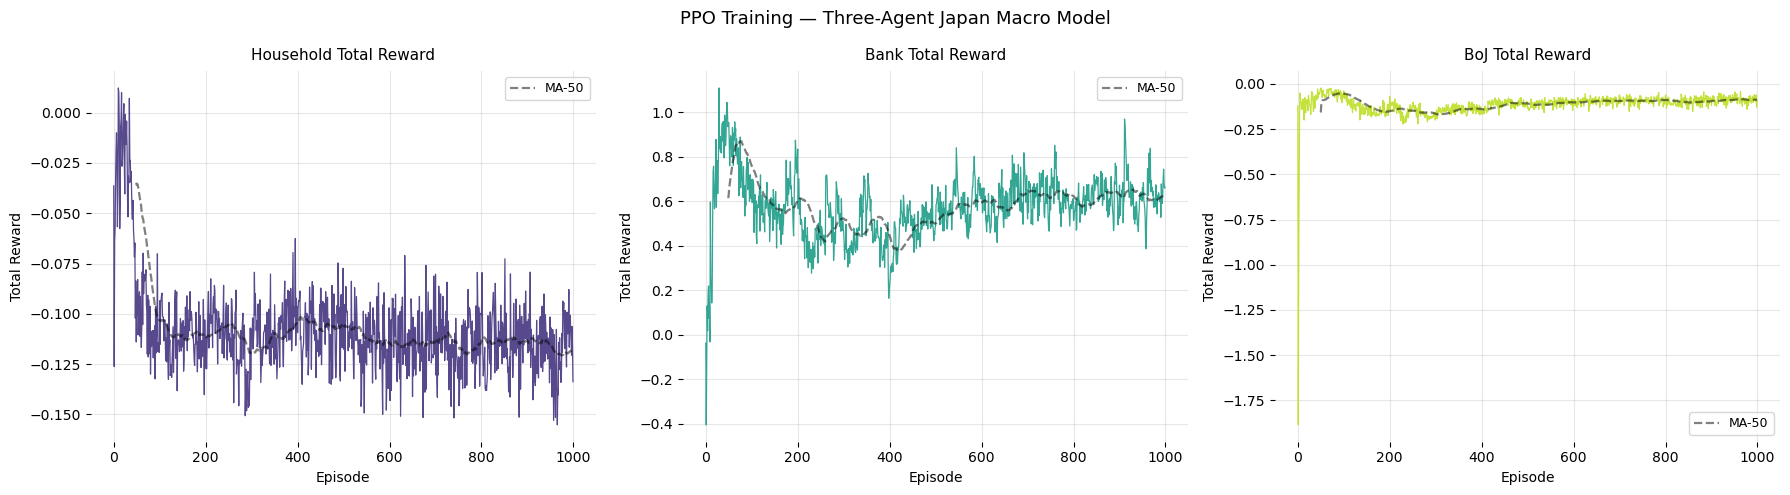

In [226]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

vir = cm.get_cmap("viridis")
c_hh, c_bank, c_boj = vir(0.15), vir(0.55), vir(0.90)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PPO Training — Three-Agent Japan Macro Model", fontsize=13)

pairs = [
    (axes[0], history["hh"],   c_hh,   "Household Total Reward"),
    (axes[1], history["bank"], c_bank, "Bank Total Reward"),
    (axes[2], history["boj"],  c_boj,  "BoJ Total Reward"),
]

for ax, data, color, title in pairs:
    ax.plot(data, color=color, linewidth=0.9, alpha=0.9)

    window = 50
    smooth = np.convolve(data, np.ones(window)/window, mode="valid")
    ax.plot(range(window-1, len(data)), smooth,
            color="black", linewidth=1.6, alpha=0.5, linestyle="--", label="MA-50")

    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Episode", fontsize=10)
    ax.set_ylabel("Total Reward", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)       

plt.tight_layout()
plt.show()

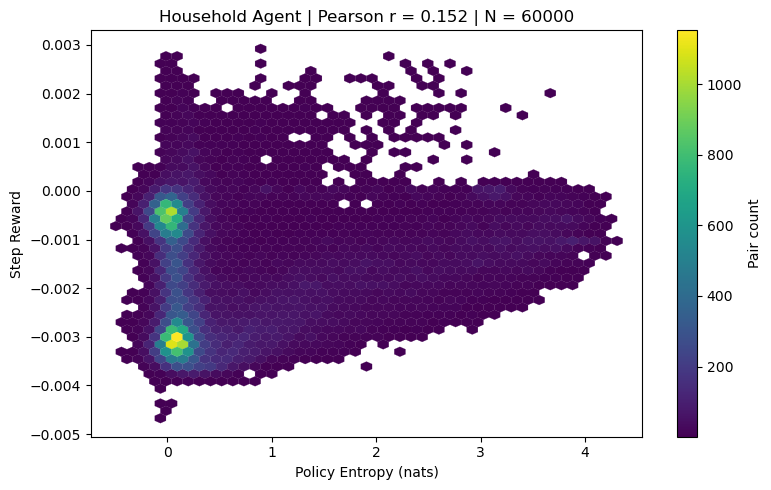

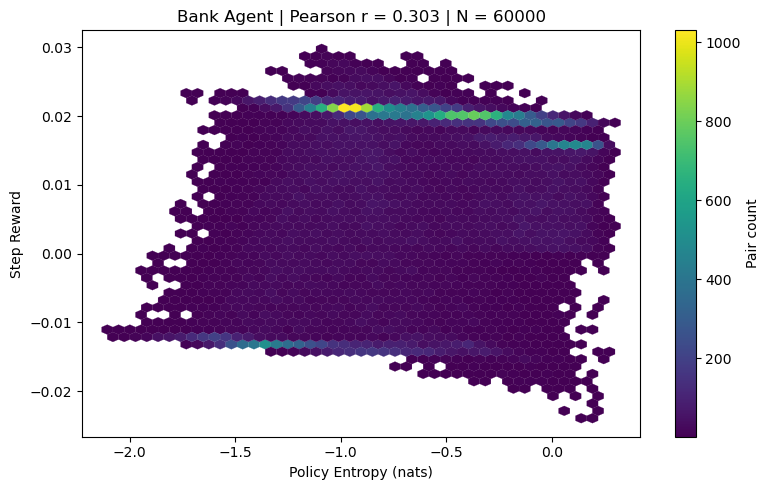

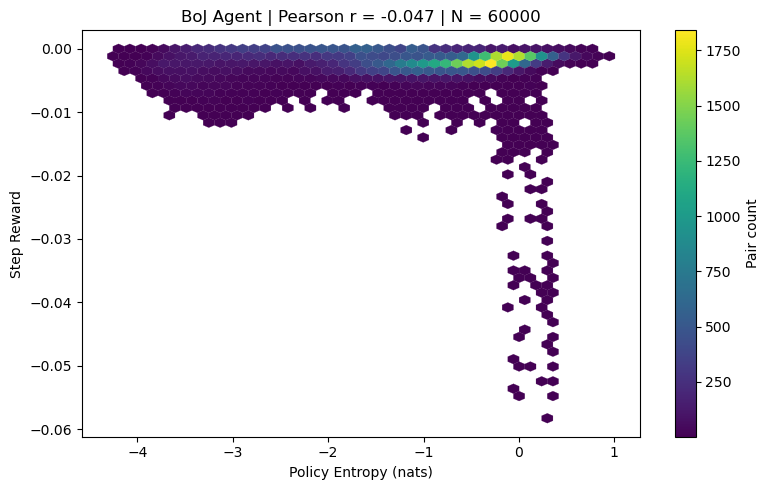

In [227]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

hh_ent   = np.array(history["hh_ent"])
bank_ent = np.array(history["bank_ent"])
boj_ent  = np.array([float(np.sum(x)) for x in history["boj_ent"]])

hh_rwd   = np.array(history["hh_step_rwd"])
bank_rwd = np.array(history["bank_step_rwd"])
boj_rwd  = np.array(history["boj_step_rwd"])

agents = [
    ("Household Agent", hh_ent, hh_rwd, "household_entropy_reward.png"),
    ("Bank Agent", bank_ent, bank_rwd, "bank_entropy_reward.png"),
    ("BoJ Agent", boj_ent, boj_rwd, "boj_entropy_reward.png"),
]

for name, ent, rwd, filename in agents:
    mask = np.isfinite(ent) & np.isfinite(rwd)
    ent, rwd = ent[mask], rwd[mask]

    r, _ = stats.pearsonr(ent, rwd)

    fig, ax = plt.subplots(figsize=(8, 5))
    hb = ax.hexbin(ent, rwd, gridsize=45, cmap="viridis", mincnt=1, linewidths=0.15)

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Pair count")

    ax.set_title(f"{name} | Pearson r = {r:.3f} | N = {len(ent)}")
    ax.set_xlabel("Policy Entropy (nats)")
    ax.set_ylabel("Step Reward")

    plt.tight_layout()
    plt.show()

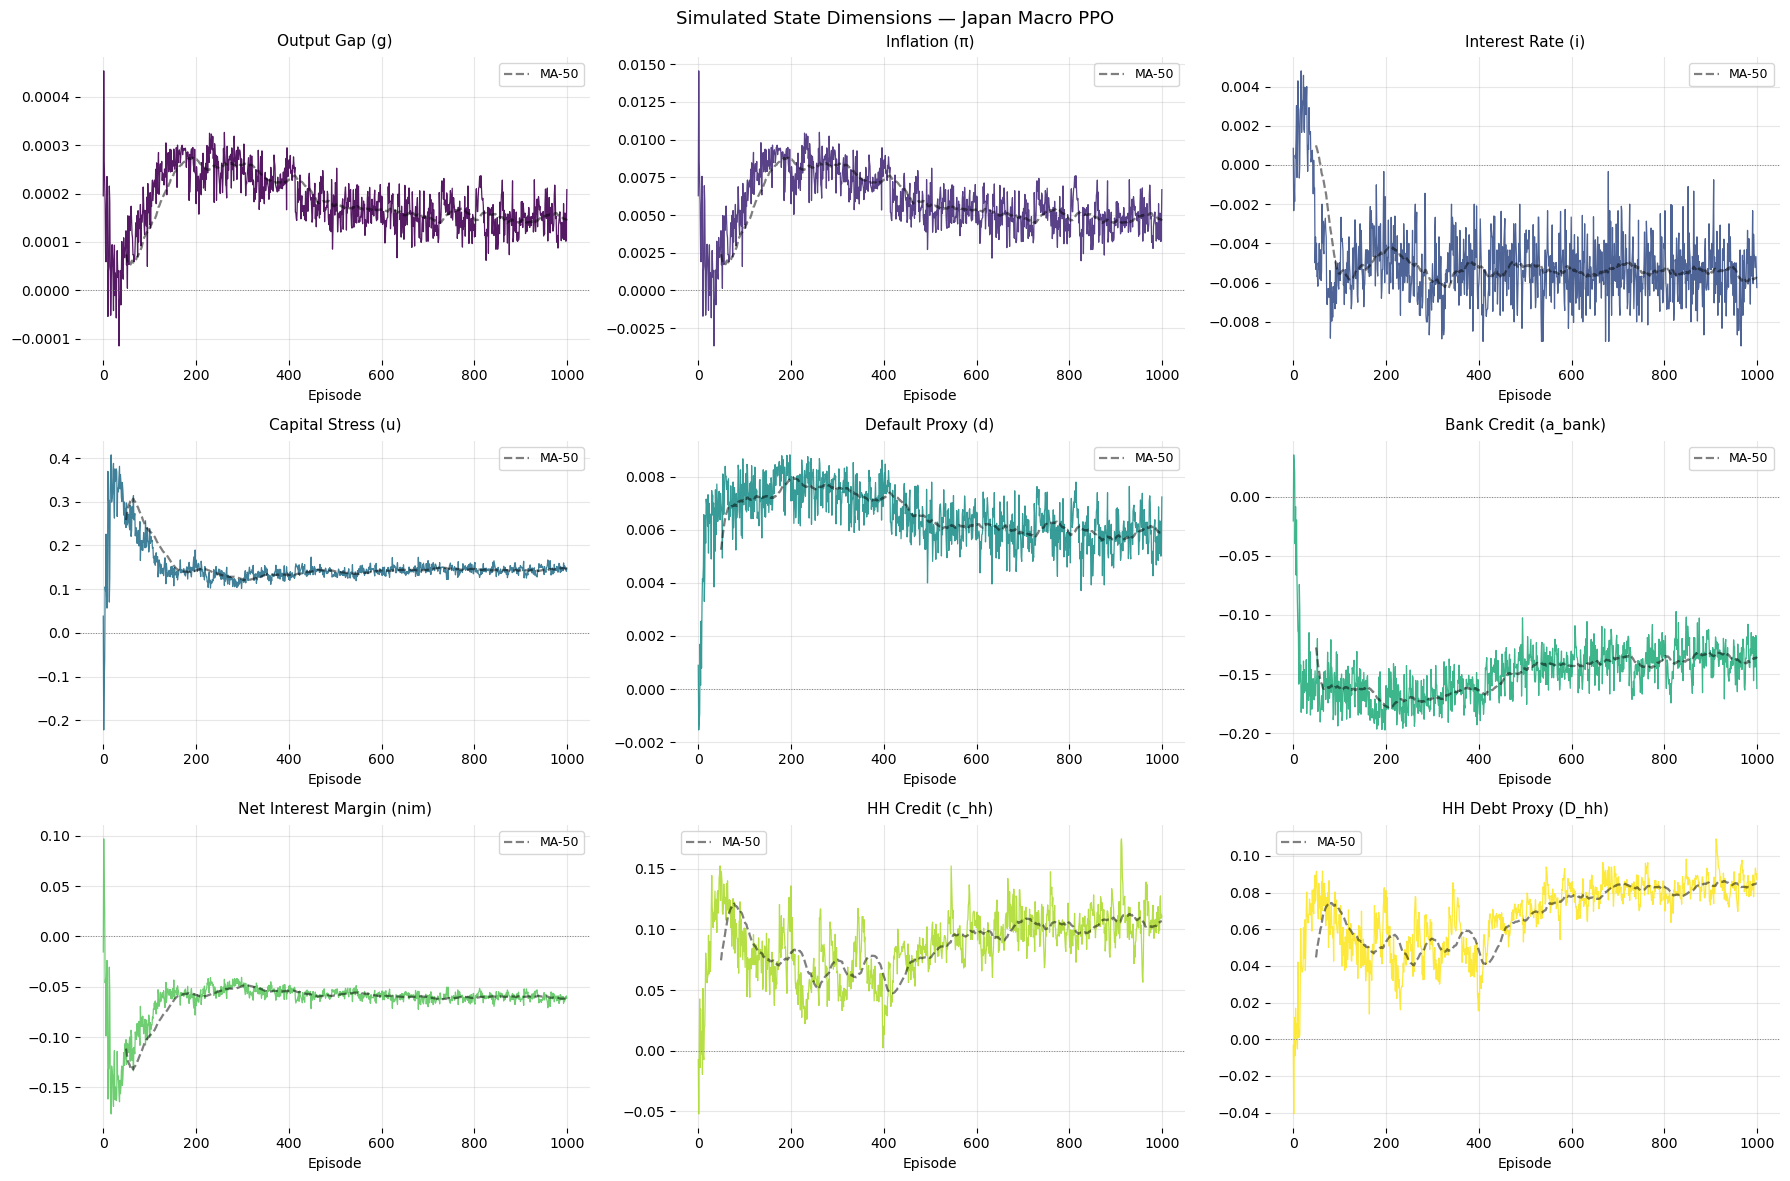

In [228]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

labels = [
    "Output Gap (g)",
    "Inflation (π)",
    "Interest Rate (i)",
    "Capital Stress (u)",
    "Default Proxy (d)",
    "Bank Credit (a_bank)",
    "Net Interest Margin (nim)",
    "HH Credit (c_hh)",
    "HH Debt Proxy (D_hh)",
]

vir    = cm.get_cmap("viridis")
colors = [vir(i / 8) for i in range(9)]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle("Simulated State Dimensions — Japan Macro PPO", fontsize=13)

for i, (ax, label, color) in enumerate(zip(axes.flat, labels, colors)):
    data = history["state_dims"][i]

    ax.plot(data, color=color, linewidth=0.9, alpha=0.9)

    window = 50
    if len(data) >= window:
        smooth = np.convolve(data, np.ones(window)/window, mode="valid")
        ax.plot(range(window-1, len(data)), smooth,
                color="black", linewidth=1.6, alpha=0.5,
                linestyle="--", label="MA-50")

    ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")
    ax.set_title(label, fontsize=11, pad=8)
    ax.set_xlabel("Episode", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()